In [22]:
import zarr

dataset_path = '../dataset_generation/full_dataset/dataset.zarr'

# Open the dataset in read mode
root = zarr.open_group(dataset_path, mode='r')

dataset_size = 10000

# Access the arrays
X_flux = root["X_flux_coeffs"][:dataset_size]
X_wts  = root["X_weights"][:dataset_size]
Y_flux = root["Y_flux_coeffs"][:dataset_size]
Y_pow  = root["Y_power_coeffs"][:dataset_size]
Y_keff = root["Y_keff"][:dataset_size]
Y_wts  = root["Y_weights"][:dataset_size]

# Convert all data into pytorch tensors of the appropriate shape

import numpy as np
import torch

X_flux = np.moveaxis(X_flux, -1, 2)
Y_flux = np.moveaxis(Y_flux, -1, 2)

X_flux = torch.tensor(X_flux, dtype=torch.float32)
X_wts  = torch.tensor(X_wts, dtype=torch.float32)

Y_flux = torch.tensor(Y_flux, dtype=torch.float32)
Y_pow  = torch.tensor(Y_pow, dtype=torch.float32)
Y_keff = torch.tensor(Y_keff, dtype=torch.float32)
Y_wts  = torch.tensor(Y_wts, dtype=torch.float32)

In [23]:
import torch.nn as nn
import torch.nn.functional as F


# Flatten and concatenate inputs
X_flux_flat = X_flux.view(X_flux.size(0), -1)
X_input = torch.cat([X_flux_flat, X_wts], dim=1)

# Output sizes
out_flux_size = Y_flux.view(Y_flux.size(0), -1).size(1)
out_pow_size = Y_pow.view(Y_pow.size(0), -1).size(1)
out_wts_size = Y_wts.size(1)
out_keff_size = 1

# Define the model
class SimpleFCNN(nn.Module):
    def __init__(self, Y_flux_shape, Y_pow_shape, input_dim, hidden_dim=512):
        super().__init__()
        self.Y_flux_shape = Y_flux_shape[1:]  # drop batch dim
        self.Y_pow_shape = Y_pow_shape[1:]    # drop batch dim

        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)

        # Output heads
        self.out_flux = nn.Linear(hidden_dim, out_flux_size)
        self.out_pow = nn.Linear(hidden_dim, out_pow_size)
        self.out_keff = nn.Linear(hidden_dim, out_keff_size)
        self.out_wts = nn.Linear(hidden_dim, out_wts_size)

    def forward(self, X_flux, X_wts):
        # Flatten inputs internally
        X_flux_flat = X_flux.view(X_flux.size(0), -1)
        X = torch.cat([X_flux_flat, X_wts], dim=1)

        x = F.relu(self.fc1(X))
        x = F.relu(self.fc2(x))

        return {
            'flux': self.out_flux(x).view(-1, *self.Y_flux_shape),
            'pow': self.out_pow(x).view(-1, *self.Y_pow_shape),
            'keff': self.out_keff(x).squeeze(-1),
            'wts': self.out_wts(x)
        }


In [24]:
mse = nn.MSELoss()

def compute_loss(pred, Y_flux, Y_pow, Y_keff, Y_wts):
    return (
        mse(pred['flux'], Y_flux) +
        mse(pred['pow'], Y_pow) +
        mse(pred['keff'], Y_keff) +
        mse(pred['wts'], Y_wts)
    )


In [25]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import torch

seed = 42
torch.manual_seed(seed)

# === Flatten tensors where necessary ===
X_flux_flat = X_flux.view(X_flux.size(0), -1).numpy()
X_wts_np    = X_wts.numpy()
Y_flux_flat = Y_flux.view(Y_flux.size(0), -1).numpy()
Y_pow_flat  = Y_pow.view(Y_pow.size(0), -1).numpy()  # <-- fix applied here
Y_keff_np   = Y_keff.view(-1, 1).numpy()
Y_wts_np    = Y_wts.numpy()

# === Create train/test splits in NumPy ===
(
    X_flux_train_np, X_flux_test_np,
    X_wts_train_np, X_wts_test_np,
    Y_flux_train_np, Y_flux_test_np,
    Y_pow_train_np, Y_pow_test_np,
    Y_keff_train_np, Y_keff_test_np,
    Y_wts_train_np, Y_wts_test_np
) = train_test_split(
    X_flux_flat, X_wts_np,
    Y_flux_flat, Y_pow_flat, Y_keff_np, Y_wts_np,
    test_size=0.2, random_state=42
)

# === Fit scalers only on training data ===
scalers = {
    'X_flux': StandardScaler().fit(X_flux_train_np),
    'X_wts': StandardScaler().fit(X_wts_train_np),
    'Y_flux': StandardScaler().fit(Y_flux_train_np),
    'Y_pow': StandardScaler().fit(Y_pow_train_np),
    'Y_keff': StandardScaler().fit(Y_keff_train_np),
    'Y_wts': StandardScaler().fit(Y_wts_train_np),
}

# === Transform both train and test sets ===
X_flux_train = torch.tensor(scalers['X_flux'].transform(X_flux_train_np), dtype=torch.float32).view(-1, *X_flux.shape[1:])
X_flux_test  = torch.tensor(scalers['X_flux'].transform(X_flux_test_np),  dtype=torch.float32).view(-1, *X_flux.shape[1:])

X_wts_train = torch.tensor(scalers['X_wts'].transform(X_wts_train_np), dtype=torch.float32)
X_wts_test  = torch.tensor(scalers['X_wts'].transform(X_wts_test_np),  dtype=torch.float32)

Y_flux_train = torch.tensor(scalers['Y_flux'].transform(Y_flux_train_np), dtype=torch.float32).view(-1, *Y_flux.shape[1:])
Y_flux_test  = torch.tensor(scalers['Y_flux'].transform(Y_flux_test_np),  dtype=torch.float32).view(-1, *Y_flux.shape[1:])

Y_pow_train = torch.tensor(scalers['Y_pow'].transform(Y_pow_train_np), dtype=torch.float32)
Y_pow_test  = torch.tensor(scalers['Y_pow'].transform(Y_pow_test_np),  dtype=torch.float32)

Y_keff_train = torch.tensor(scalers['Y_keff'].transform(Y_keff_train_np), dtype=torch.float32).squeeze(1)
Y_keff_test  = torch.tensor(scalers['Y_keff'].transform(Y_keff_test_np),  dtype=torch.float32).squeeze(1)

Y_wts_train = torch.tensor(scalers['Y_wts'].transform(Y_wts_train_np), dtype=torch.float32)
Y_wts_test  = torch.tensor(scalers['Y_wts'].transform(Y_wts_test_np),  dtype=torch.float32)

In [26]:
from torch.utils.data import TensorDataset, DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# === 1. Wrap pre-normalized train and test tensors ===
train_set = TensorDataset(X_flux_train, X_wts_train, Y_flux_train, Y_pow_train, Y_keff_train, Y_wts_train)
test_set  = TensorDataset(X_flux_test,  X_wts_test,  Y_flux_test,  Y_pow_test,  Y_keff_test,  Y_wts_test)

# === 2. Create DataLoaders ===
batch_size = 1000

train_loader = DataLoader(train_set, batch_size=batch_size)  # full-batch for now
test_loader = DataLoader(test_set, batch_size=len(test_set))

# === 3. Get one full batch from train set to define input_dim ===
X_flux_train, X_wts_train, Y_flux_train, Y_pow_train, Y_keff_train, Y_wts_train = next(iter(train_loader))

# === 4. Instantiate model with shape info ===
X_input_dim = X_flux_train.view(X_flux_train.size(0), -1).size(1) + X_wts_train.size(1)
model = SimpleFCNN(Y_flux_train.shape, Y_pow_train.shape, input_dim=X_input_dim).to(device)

# Weight initialization
def init_weights(m):
    if isinstance(m, nn.Conv3d):
        nn.init.kaiming_normal_(m.weight)
        if m.bias is not None:
            nn.init.zeros_(m.bias)
    elif isinstance(m, nn.ConvTranspose3d):
        nn.init.kaiming_normal_(m.weight)
        if m.bias is not None:
            nn.init.zeros_(m.bias)
    elif isinstance(m, nn.Linear):
        nn.init.kaiming_normal_(m.weight)
        if m.bias is not None:
            nn.init.zeros_(m.bias)
            
model.apply(init_weights)

num_params = sum(p.numel() for p in model.parameters())
print(f"Total number of parameters: {num_params}")

Total number of parameters: 1477341


In [27]:
from tqdm import tqdm

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
epochs = 100
progress_bar = tqdm(range(epochs), desc="Training", position=0)

train_losses = []
test_losses = []
for epoch in progress_bar:
    model.train()

    for X_flux_batch, X_wts_batch, Y_flux_batch, Y_pow_batch, Y_keff_batch, Y_wts_batch in train_loader:
        X_flux_batch = X_flux_batch.to(device)
        X_wts_batch  = X_wts_batch.to(device)
        Y_flux_batch = Y_flux_batch.to(device)
        Y_pow_batch  = Y_pow_batch.to(device)
        Y_keff_batch = Y_keff_batch.to(device)
        Y_wts_batch  = Y_wts_batch.to(device)
        
        pred = model(X_flux_batch, X_wts_batch)
        loss = compute_loss(pred, Y_flux_batch, Y_pow_batch, Y_keff_batch, Y_wts_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    
    model.eval()
    with torch.no_grad():
        for X_flux_test, X_wts_test, Y_flux_test, Y_pow_test, Y_keff_test, Y_wts_test in test_loader:
            X_flux_test = X_flux_test.to(device)
            X_wts_test  = X_wts_test.to(device)
            Y_flux_test = Y_flux_test.to(device)
            Y_pow_test  = Y_pow_test.to(device)
            Y_keff_test = Y_keff_test.to(device)
            Y_wts_test  = Y_wts_test.to(device)

            pred_test = model(X_flux_test, X_wts_test)
            test_loss = compute_loss(pred_test, Y_flux_test, Y_pow_test, Y_keff_test, Y_wts_test)

    train_losses.append(loss.item())
    test_losses.append(test_loss.item())
    progress_bar.set_description(f"Epoch {epoch}/{epochs}: Train Loss = {loss.item():.4f} | Test Loss = {test_loss.item():.4f}")

# === 8. Evaluate on test set ===
model.eval()
with torch.no_grad():
    for X_flux_test, X_wts_test, Y_flux_test, Y_pow_test, Y_keff_test, Y_wts_test in test_loader:
        X_flux_test = X_flux_test.to(device)
        X_wts_test  = X_wts_test.to(device)
        Y_flux_test = Y_flux_test.to(device)
        Y_pow_test  = Y_pow_test.to(device)
        Y_keff_test = Y_keff_test.to(device)
        Y_wts_test  = Y_wts_test.to(device)

        pred_test = model(X_flux_test, X_wts_test)
        test_loss = compute_loss(pred_test, Y_flux_test, Y_pow_test, Y_keff_test, Y_wts_test)

print(f"Final Test Loss: {test_loss.item():.4f}")


Epoch 99/100: Train Loss = 0.9596 | Test Loss = 11.2129: 100%|██████████| 100/100 [00:25<00:00,  3.97it/s]

Final Test Loss: 11.2129


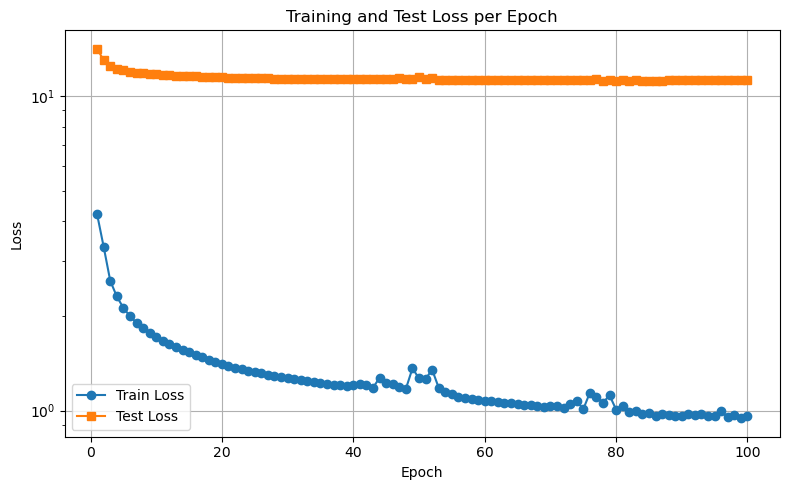

In [28]:
import matplotlib.pyplot as plt

epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_losses, label='Train Loss', marker='o')
plt.plot(epochs, test_losses, label='Test Loss', marker='s')
plt.yscale('log')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Test Loss per Epoch')
plt.legend()
plt.grid()
plt.tight_layout()
plt.savefig("loss_curve.png", dpi=300)

In [29]:
class ScaledModelWrapper:
    def __init__(self, model, scalers, device="cpu"):
        self.model = model.to(device)
        self.scalers = scalers
        self.device = device

    def _normalize_input(self, X_flux, X_wts):
        X_flux_flat = X_flux.view(X_flux.size(0), -1).numpy()
        X_wts_np = X_wts.numpy()

        X_flux_scaled = self.scalers['X_flux'].transform(X_flux_flat)
        X_wts_scaled = self.scalers['X_wts'].transform(X_wts_np)

        X_flux_tensor = torch.tensor(X_flux_scaled, dtype=torch.float32).view_as(X_flux).to(self.device)
        X_wts_tensor = torch.tensor(X_wts_scaled, dtype=torch.float32).to(self.device)

        return X_flux_tensor, X_wts_tensor

    def _denormalize_output(self, out):
        out_denorm = {}

        Y_flux_flat = out['flux'].view(out['flux'].size(0), -1).cpu().numpy()
        out_denorm['flux'] = torch.tensor(
            self.scalers['Y_flux'].inverse_transform(Y_flux_flat),
            dtype=torch.float32
        ).view_as(out['flux'])

        Y_pow_flat = out['pow'].view(out['pow'].size(0), -1).cpu().numpy()
        out_denorm['pow'] = torch.tensor(
            self.scalers['Y_pow'].inverse_transform(Y_pow_flat),
            dtype=torch.float32
        )

        Y_keff = out['keff'].view(-1, 1).cpu().numpy()
        out_denorm['keff'] = torch.tensor(
            self.scalers['Y_keff'].inverse_transform(Y_keff),
            dtype=torch.float32
        ).squeeze(1)

        Y_wts = out['wts'].cpu().numpy()
        out_denorm['wts'] = torch.tensor(
            self.scalers['Y_wts'].inverse_transform(Y_wts),
            dtype=torch.float32
        )

        return out_denorm

    def predict(self, X_flux, X_wts):
        self.model.eval()
        with torch.no_grad():
            X_flux_norm, X_wts_norm = self._normalize_input(X_flux, X_wts)
            out = self.model(X_flux_norm, X_wts_norm)
            out_denorm = self._denormalize_output(out)
        return out_denorm


In [30]:
wrapped_model = ScaledModelWrapper(model, scalers)

test_index = -20
X_flux_sample = X_flux[test_index:test_index+1].cpu()
X_wts_sample  = X_wts[test_index:test_index+1].cpu()

out = wrapped_model.predict(X_flux_sample, X_wts_sample)

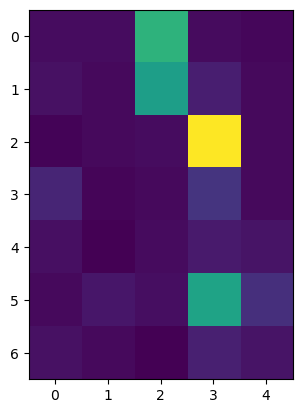

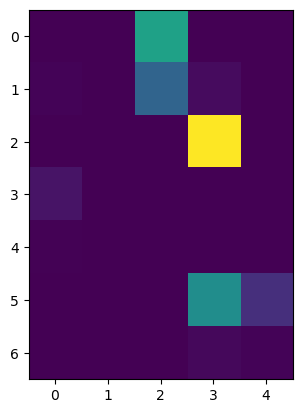

In [31]:
import matplotlib.pyplot as plt

plt.imshow(out['flux'][0, 0, 0, :, :, 0])
plt.show()
plt.imshow(Y_flux[test_index, 0, 0, :, :, 0])
plt.show()

In [32]:
out['keff'], Y_keff[test_index]

(tensor([0.7190]), tensor(0.7324))

In [33]:
out['wts'], Y_wts[test_index]

(tensor([[0.2960, 0.2947, 0.2011, 0.2135]]),
 tensor([0.2955, 0.2928, 0.2002, 0.2115]))

## Compare the Full Flux Surface Expansion

In [34]:
from pincell_moment_utils import postprocessing as pp
from pincell_moment_utils.datagen import DefaultPincellParameters

energy_filters = DefaultPincellParameters().get_energy_filters()

pred_coefficients = np.moveaxis(out['flux'][0].cpu().numpy(), 1, -1)
true_coefficients = np.moveaxis(Y_flux[test_index].cpu().numpy(), 1, -1)

pred_expansion = pp.surface_expansion(np.clip(pred_coefficients, a_min=0, a_max=None), energy_filters, expansion_type='bernstein_bernstein')
expansion = pp.surface_expansion(true_coefficients, energy_filters, expansion_type='bernstein_bernstein')

In [35]:
np.clip(pred_coefficients, a_min=0, a_max=None)

array([[[[[2.92801373e-02],
          [2.02734675e-02],
          [5.61883266e-04],
          ...,
          [5.37604308e-07],
          [0.00000000e+00],
          [5.15281845e-11]],

         [[3.78548466e-02],
          [0.00000000e+00],
          [0.00000000e+00],
          ...,
          [9.01797762e-07],
          [2.65040323e-09],
          [1.56014446e-09]],

         [[3.13634539e+00],
          [2.47411299e+00],
          [1.46861005e+00],
          ...,
          [3.58689067e-05],
          [1.88481565e-07],
          [1.05883595e-08]],

         [[1.73366554e-02],
          [9.45440202e-04],
          [2.34101601e-02],
          ...,
          [5.63284402e-07],
          [5.60405777e-10],
          [1.72512612e-12]],

         [[0.00000000e+00],
          [5.10746092e-02],
          [7.42081909e-07],
          ...,
          [0.00000000e+00],
          [2.26982587e-14],
          [0.00000000e+00]]],


        [[[9.91613567e-02],
          [0.00000000e+00],
          [0.0000

In [36]:
true_coefficients[0, :, :, 0]

array([[[0.        ],
        [0.        ],
        [3.7583897 ],
        [0.        ],
        [0.        ]],

       [[0.06658287],
        [0.        ],
        [2.1185129 ],
        [0.19180672],
        [0.        ]],

       [[0.        ],
        [0.        ],
        [0.        ],
        [6.58094   ],
        [0.        ]],

       [[0.34700775],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ]],

       [[0.04886367],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ]],

       [[0.        ],
        [0.        ],
        [0.        ],
        [3.2240427 ],
        [0.885784  ]],

       [[0.        ],
        [0.        ],
        [0.        ],
        [0.12899669],
        [0.05264866]]], dtype=float32)

In [37]:
pred_expansion.integrate_flux(0), expansion.integrate_flux(0)

(1.041023476688856, 0.999999937323981)

/home/mlouis9/shared/Educational Stuffs/Classes/Spring 2025/Stat ML/Project/data_generation/src/pincell_moment_utils/plotting.py:48: RuntimeWarning: invalid value encountered in divide
  expansion_vals = np.abs(expansion_vals) / np.abs(compare_expansion.evaluate_on_grid(surface, (space_vals, angle_vals, energy_vals)))


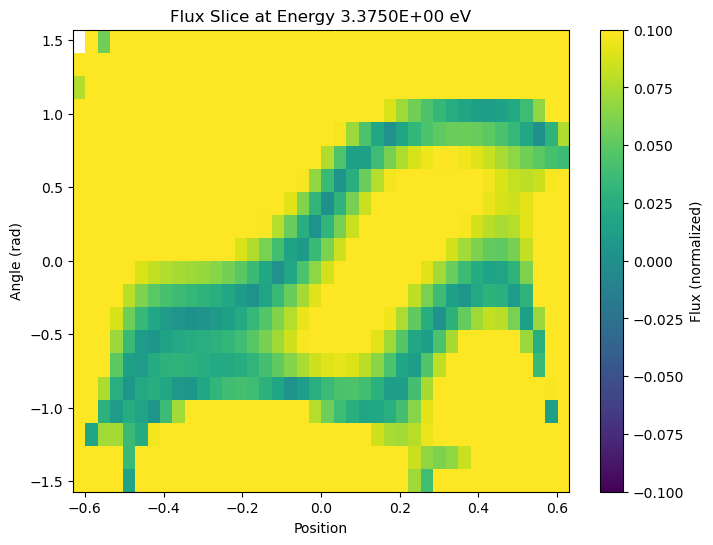

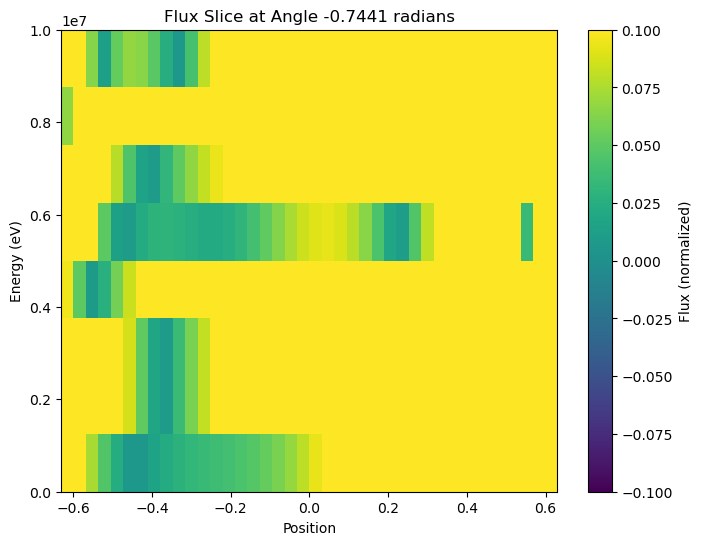

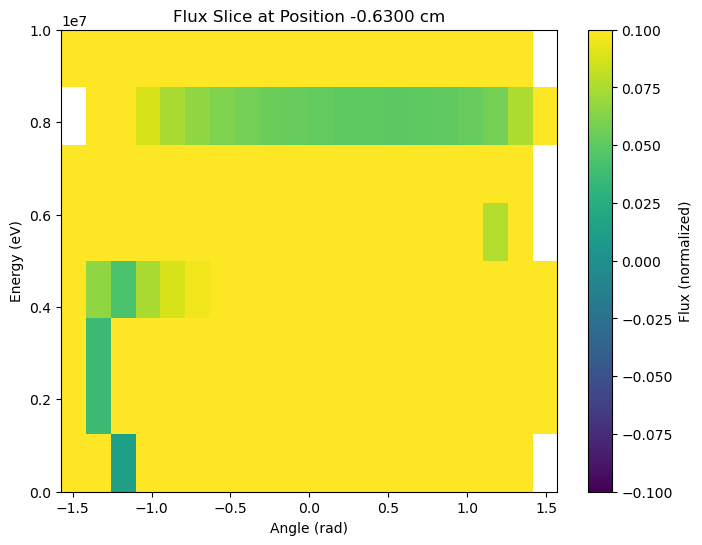

In [38]:
from pincell_moment_utils.plotting import plot_expansion

plot_expansion(expansion, 0, 5, 4, 0, 40, 20, incident=False, compare_expansion=pred_expansion)

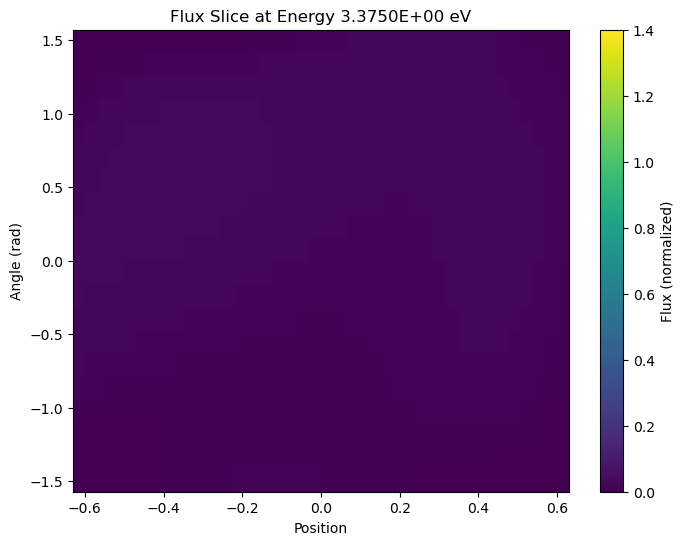

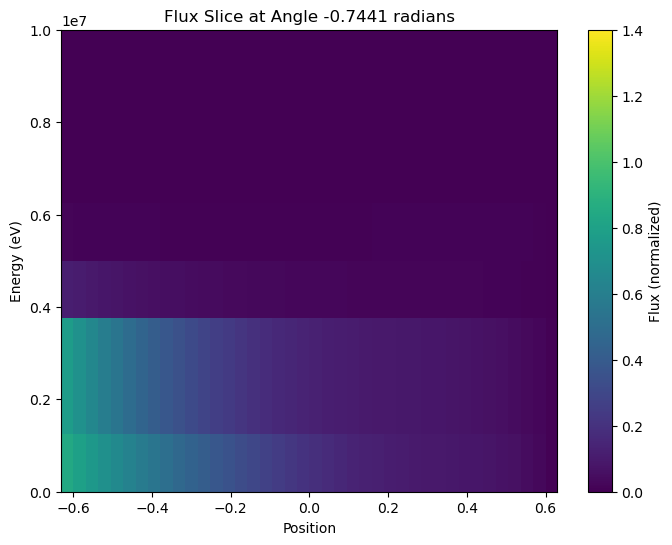

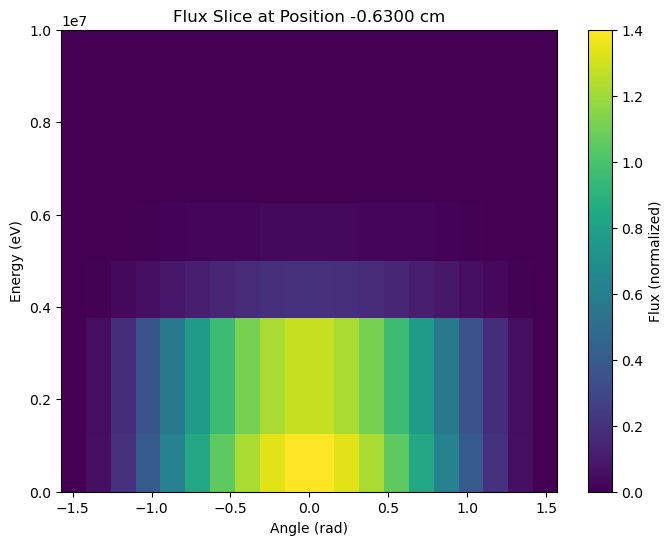

In [39]:
plot_expansion(expansion, 0, 5, 4, 0, 40, 20, incident=False)

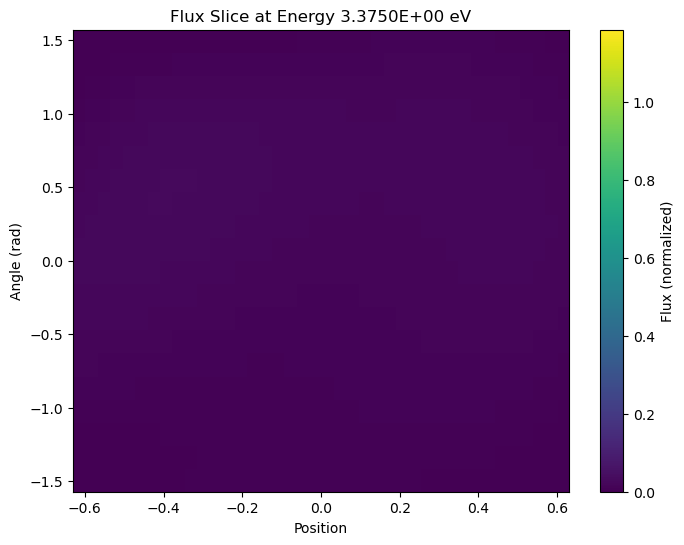

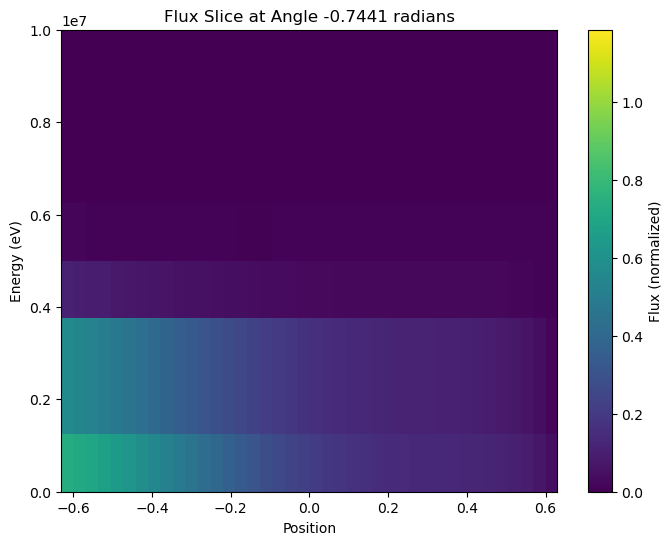

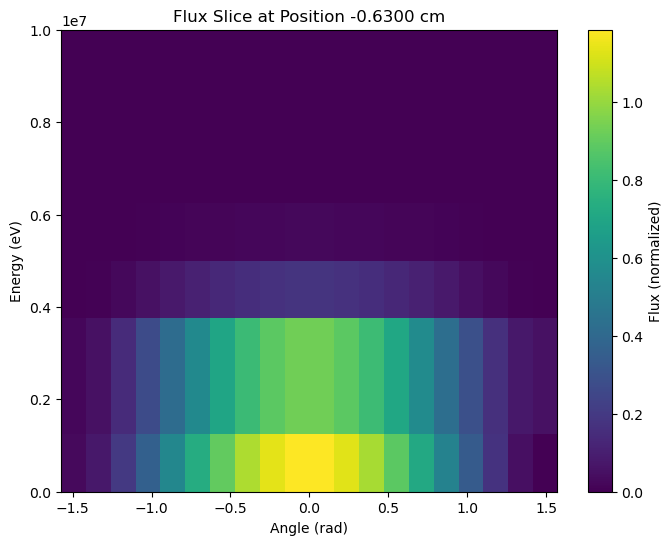

In [40]:
plot_expansion(pred_expansion, 0, 5, 4, 0, 40, 20, incident=False)